### Polynomial Regression Implementation

In [13]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

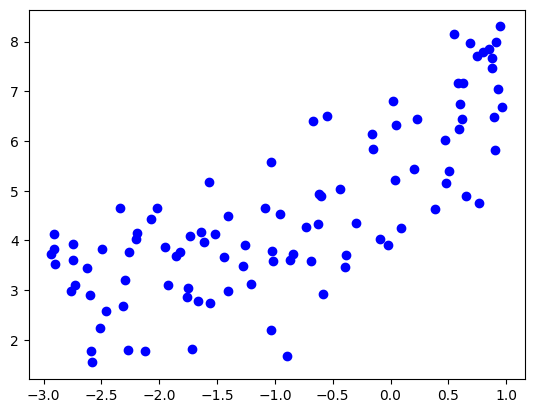

In [2]:
#generating sample data using quadratic equations

x = 4*np.random.rand(100,1)-3

y = 0.5*x**2 + 2*x + 5+ np.random.randn(100,1)

plt.scatter(x,y, color='b')

In [3]:
#getting train and test dataset

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(75, 1)
(25, 1)
(75, 1)
(25, 1)


In [4]:
#implementation of linear regression

regressor = LinearRegression()

regressor.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
y_pred = regressor.predict(x_test)

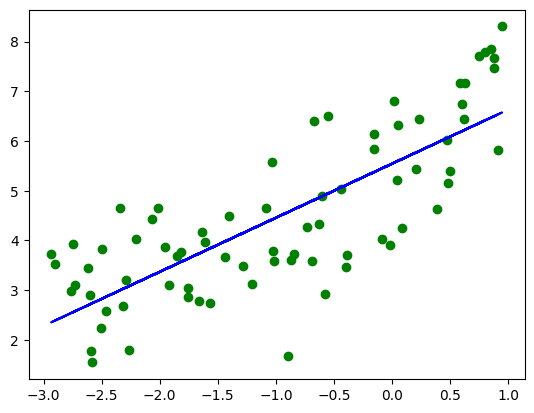

In [6]:
#plotting regression line on dataset
plt.scatter(x_train, y_train, color='g')
plt.plot(x_train, regressor.predict(x_train), color='b')

In [7]:
#creating polynomial features of degree 2

polynomial_obj = PolynomialFeatures(degree=2)
x_train_poly_2_degree = polynomial_obj.fit_transform(x_train)
x_test_poly_2_degree = polynomial_obj.transform(x_test)

In [8]:
#using above polynomial features for training linear regression model

poly_regressor = LinearRegression()

poly_regressor.fit(x_train_poly_2_degree, y_train)

y_pred_poly = poly_regressor.predict(x_test_poly_2_degree)

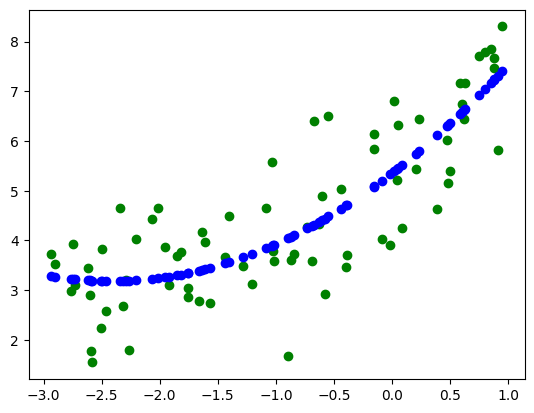

In [9]:
#plotting it visually

plt.scatter(x_train, y_train, color='g')
plt.scatter(x_train, poly_regressor.predict(x_train_poly_2_degree), color='b')


In [ ]:
#performance metrics

mse = mean_squared_error(y_test, y_pred_poly)
mae = mean_absolute_error(y_test, y_pred_poly)

print(f"Mean Squared Error: {mse}\nMean Absolute Error: {mae}")

Mean Squared Error: 1.1702094165856307
Mean Absolute Error: 0.93208790087095


In [15]:
#r_sqaured and adjusted r_squared values

score = r2_score(y_test, y_pred_poly)
adjusted_r_score =  1-((1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))

print(f"R Squared Error: {score}\nAdjusted R Squared Error: {adjusted_r_score}")

R Squared Error: 0.633367006305836
Adjusted R Squared Error: 0.6174264413626114


In [10]:
#using higher degree polynomial feature to see best fit curve

#creating polynomial features of degree 10

polynomial_10_obj = PolynomialFeatures(degree=10)
x_train_poly_10_degree = polynomial_10_obj.fit_transform(x_train)
x_test_poly_10_degree = polynomial_10_obj.transform(x_test)



In [11]:
poly10_regressor = LinearRegression()

poly10_regressor.fit(x_train_poly_10_degree, y_train)

y_pred_10poly = poly10_regressor.predict(x_test_poly_10_degree)

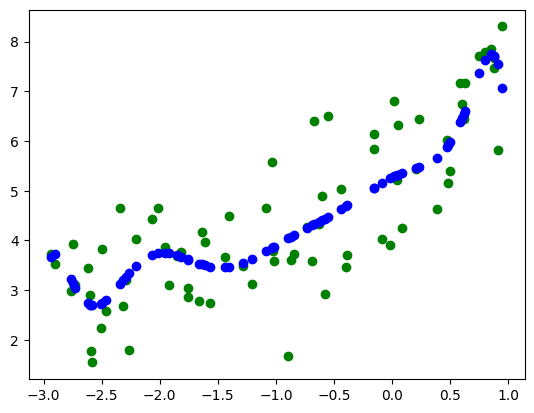

In [12]:
#plotting it visually

plt.scatter(x_train, y_train, color='g')
plt.scatter(x_train, poly10_regressor.predict(x_train_poly_10_degree), color='b')

In [16]:
#performance metrics

mse = mean_squared_error(y_test, y_pred_10poly)
mae = mean_absolute_error(y_test, y_pred_10poly)

print(f"Mean Squared Error: {mse}\nMean Absolute Error: {mae}")

Mean Squared Error: 1.3025496220534762
Mean Absolute Error: 0.8892123676369882


In [17]:
#r_sqaured and adjusted r_squared values

score = r2_score(y_test, y_pred_10poly)
adjusted_r_score =  1-((1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))

print(f"R Squared Error: {score}\nAdjusted R Squared Error: {adjusted_r_score}")

R Squared Error: 0.5919040980185768
Adjusted R Squared Error: 0.5741607979324279


Observation:

performance degraded as we increase degree in polynomial feature